In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    recall_score,
    precision_score,
    f1_score,
    precision_recall_curve,
    auc,
)
from imblearn.over_sampling import SMOTE

In [3]:
# Load Data
df = pd.read_csv("../data/processed/dataset_clean.csv", parse_dates=["timestamp"])

In [4]:
# Splitting Data
df_sorted = df.sort_values("timestamp").reset_index(drop=True)

FEATURE_COLS = [
    "age_months", "last_maintenance_days",
    "temp_c", "vibration_mm_s", "current_a",
    "load_pct", "lubricant_level_pct", "alarm_count",
]
TARGET = "downtime_next_24h"

X_sorted = df_sorted[FEATURE_COLS]
y_sorted = df_sorted[TARGET]

split_idx = int(len(df_sorted) * 0.8)
X_train, X_test = X_sorted.iloc[:split_idx], X_sorted.iloc[split_idx:]
y_train, y_test = y_sorted.iloc[:split_idx], y_sorted.iloc[split_idx:]

print(f"Train : {len(X_train)} baris ({y_train.sum()} downtime, rate {y_train.mean()*100:.1f}%)")
print(f"Test  : {len(X_test)} baris ({y_test.sum()} downtime, rate {y_test.mean()*100:.1f}%)")

Train : 1920 baris (45 downtime, rate 2.3%)
Test  : 480 baris (22 downtime, rate 4.6%)


In [5]:
# Scaling Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [6]:
# SMOTE 
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_scaled, y_train)
print(f"Distribusi setelah SMOTE: {dict(pd.Series(y_res).value_counts())}")

Distribusi setelah SMOTE: {0: 1875, 1: 1875}


In [7]:
# Logistic Regression
lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr.fit(X_res, y_res)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [8]:
# Random Forest
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)
rf.fit(X_res, y_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [9]:
# Training + Hasil 
proba_lr = lr.predict_proba(X_test_scaled)[:, 1]
proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

# Prediksi dengan threshold default 0.50
y_pred_lr_base = (proba_lr >= 0.50).astype(int)
y_pred_rf_base = (proba_rf >= 0.50).astype(int)

print("=" * 55)
print("=== BASELINE: Logistic Regression (threshold=0.50) ===")
print(classification_report(y_test, y_pred_lr_base, target_names=["Normal", "Downtime"]))

print("=" * 55)
print("=== BASELINE: Random Forest (threshold=0.50) ===")
print(classification_report(y_test, y_pred_rf_base, target_names=["Normal", "Downtime"]))


=== BASELINE: Logistic Regression (threshold=0.50) ===
              precision    recall  f1-score   support

      Normal       0.98      0.74      0.84       458
    Downtime       0.12      0.73      0.20        22

    accuracy                           0.74       480
   macro avg       0.55      0.73      0.52       480
weighted avg       0.94      0.74      0.81       480

=== BASELINE: Random Forest (threshold=0.50) ===
              precision    recall  f1-score   support

      Normal       0.95      0.98      0.96       458
    Downtime       0.00      0.00      0.00        22

    accuracy                           0.93       480
   macro avg       0.48      0.49      0.48       480
weighted avg       0.91      0.93      0.92       480



In [10]:
# Tunning
print("Logistic Regression — Analisis Threshold:")
print(f"{'Threshold':<12} {'Recall':<10} {'FAR':<10} {'TP':<6} {'FP':<6} {'FN':<6}")
print("-" * 52)

for thresh in [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]:
    preds = (proba_lr >= thresh).astype(int)
    cm    = confusion_matrix(y_test, preds)
    tn_, fp_, fn_, tp_ = cm.ravel()
    recall_ = tp_ / (tp_ + fn_)
    far_    = fp_ / (fp_ + tn_)
    marker  = " <- DIPILIH" if thresh == 0.30 else ""
    print(f"{thresh:<12.2f} {recall_:<10.1%} {far_:<10.1%} {tp_:<6} {fp_:<6} {fn_:<6}{marker}")

print("\nAlasan memilih threshold 0.30:")
print("Recall >= 80% tercapai dengan FAR yang masih dalam batas toleransi operasional.")
print("Biaya melewatkan 1 downtime >> biaya 1 alarm palsu, sehingga recall diprioritaskan.")

Logistic Regression — Analisis Threshold:
Threshold    Recall     FAR        TP     FP     FN    
----------------------------------------------------
0.50         72.7%      26.2%      16     120    6     
0.45         72.7%      29.9%      16     137    6     
0.40         81.8%      33.6%      18     154    4     
0.35         86.4%      38.6%      19     177    3     
0.30         95.5%      42.8%      21     196    1      <- DIPILIH
0.25         95.5%      48.9%      21     224    1     
0.20         95.5%      53.9%      21     247    1     

Alasan memilih threshold 0.30:
Recall >= 80% tercapai dengan FAR yang masih dalam batas toleransi operasional.
Biaya melewatkan 1 downtime >> biaya 1 alarm palsu, sehingga recall diprioritaskan.


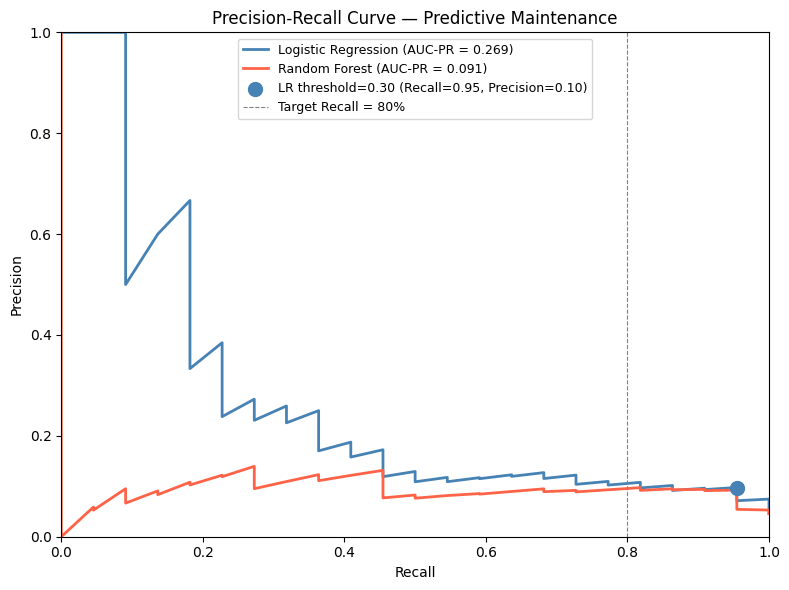

In [11]:
# Evaluasi
fig, ax = plt.subplots(figsize=(8, 6))

for proba, nama, warna in [
    (proba_lr, "Logistic Regression", "steelblue"),
    (proba_rf, "Random Forest",       "tomato"),
]:
    precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, proba)
    pr_auc = auc(recall_vals, precision_vals)
    ax.plot(recall_vals, precision_vals, color=warna, linewidth=2,
            label=f"{nama} (AUC-PR = {pr_auc:.3f})")

# Tandai posisi threshold 0.30 pada kurva LR
precision_vals_lr, recall_vals_lr, thresholds_lr = precision_recall_curve(y_test, proba_lr)
thresh_idx = np.argmin(np.abs(thresholds_lr - 0.30))
ax.scatter(recall_vals_lr[thresh_idx], precision_vals_lr[thresh_idx],
           color="steelblue", s=100, zorder=5,
           label=f"LR threshold=0.30 (Recall={recall_vals_lr[thresh_idx]:.2f}, Precision={precision_vals_lr[thresh_idx]:.2f})")

ax.axvline(0.80, color="gray", linestyle="--", linewidth=0.8, label="Target Recall = 80%")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — Predictive Maintenance")
ax.legend(fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig("../reports/figures/precision_recall_curve.png", dpi=150, bbox_inches="tight")
plt.show()


In [12]:
# Retraining
THRESH_LR = 0.30
THRESH_RF  = 0.30

y_pred_lr = (proba_lr >= THRESH_LR).astype(int)
y_pred_rf = (proba_rf >= THRESH_RF).astype(int)

print("=" * 55)
print("=== FINAL: Logistic Regression (threshold=0.30) ===")
print(classification_report(y_test, y_pred_lr, target_names=["Normal", "Downtime"]))

print("=" * 55)
print("=== FINAL: Random Forest (threshold=0.30) ===")
print(classification_report(y_test, y_pred_rf, target_names=["Normal", "Downtime"]))

print("\n=== Ringkasan KPI Final ===")
for nama, y_pred in [("Logistic Regression", y_pred_lr), ("Random Forest", y_pred_rf)]:
    cm_val = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm_val.ravel()
    recall         = tp / (tp + fn)
    far            = fp / (fp + tn)
    total_downtime = tp + fn

    print(f"\n{nama}:")
    print(f"  Recall Downtime  : {recall:.1%}  (target >= 80%)")
    print(f"  False Alarm Rate : {far:.1%}    (target <= 15%)")
    print(f"  TP (terdeteksi)  : {tp} dari {total_downtime} downtime aktual")
    print(f"  FN (terlewat)    : {fn} downtime tidak terdeteksi")
    print(f"  FP (alarm palsu) : {fp} alarm palsu")


=== FINAL: Logistic Regression (threshold=0.30) ===
              precision    recall  f1-score   support

      Normal       1.00      0.57      0.73       458
    Downtime       0.10      0.95      0.18        22

    accuracy                           0.59       480
   macro avg       0.55      0.76      0.45       480
weighted avg       0.95      0.59      0.70       480

=== FINAL: Random Forest (threshold=0.30) ===
              precision    recall  f1-score   support

      Normal       0.96      0.91      0.93       458
    Downtime       0.12      0.27      0.17        22

    accuracy                           0.88       480
   macro avg       0.54      0.59      0.55       480
weighted avg       0.92      0.88      0.90       480


=== Ringkasan KPI Final ===

Logistic Regression:
  Recall Downtime  : 95.5%  (target >= 80%)
  False Alarm Rate : 42.8%    (target <= 15%)
  TP (terdeteksi)  : 21 dari 22 downtime aktual
  FN (terlewat)    : 1 downtime tidak terdeteksi
  FP (alar

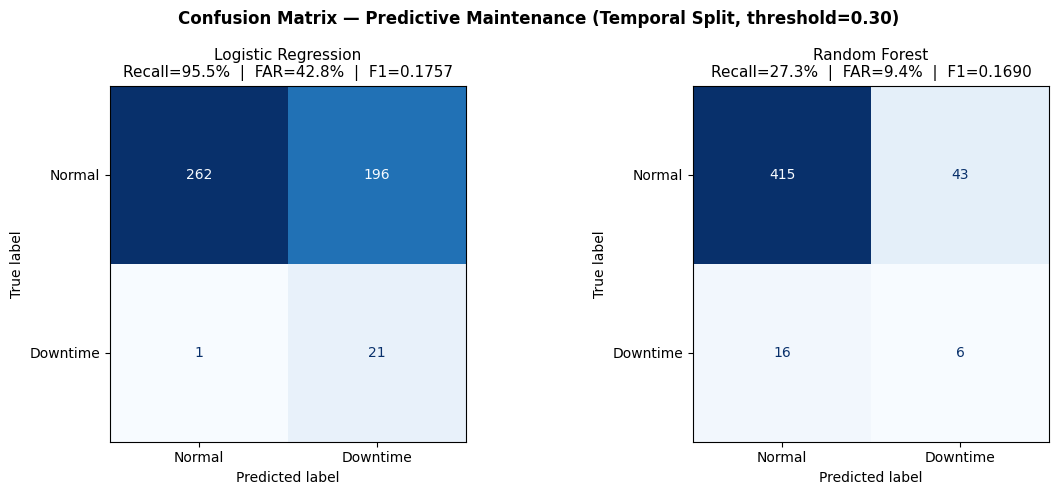

In [13]:
# Confusion Matriks 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Confusion Matrix — Predictive Maintenance (Temporal Split, threshold=0.30)",
             fontsize=12, fontweight="bold")

for ax, y_pred, nama in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ["Logistic Regression", "Random Forest"],
):
    cm_val = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm_val.ravel()
    recall_val = tp / (tp + fn)
    far_val    = fp / (fp + tn)
    f1_val = f1_score(y_test, y_pred)  # ← TAMBAH INI

    disp = ConfusionMatrixDisplay(confusion_matrix=cm_val,
                                  display_labels=["Normal", "Downtime"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{nama}\nRecall={recall_val:.1%}  |  FAR={far_val:.1%}  |  F1={f1_val:.4f}", fontsize=11)  # ← UBAH INI

plt.tight_layout()
plt.savefig("../reports/figures/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


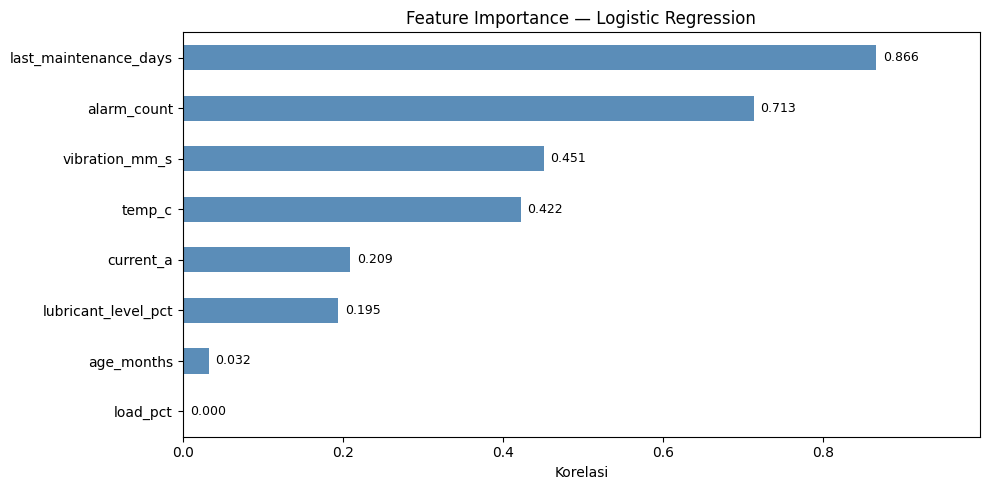

In [14]:
# Feature Importance — Logistic Regression (via koefisien)
coef = pd.Series(np.abs(lr.coef_[0]), index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))

coef.plot(kind="barh", ax=ax, color="#5B8DB8")  # satu warna semua

ax.set_title("Feature Importance — Logistic Regression")
ax.set_xlabel("Korelasi")

x_max = coef.max()
for i, v in enumerate(coef):
    ax.text(v + x_max * 0.01, i, f"{v:.3f}", va="center", fontsize=9)

ax.set_xlim(0, x_max * 1.15)

plt.tight_layout()
plt.savefig("../reports/figures/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()